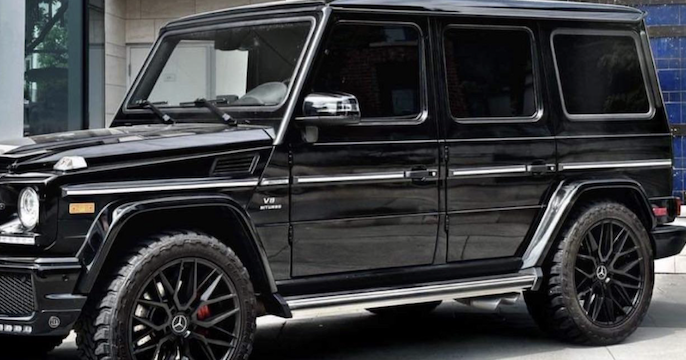

# **Car Model Identification with Bilinear CNN**

In [ ]:
from pathlib import Path
import copy
import json
import math
import random
import tarfile
import urllib.request

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import VGG16_Weights, vgg16

2.6.0+cu124


## 0. Data Preparation

In [2]:
DATA_URL = "https://www.dropbox.com/s/sakfqp6o8pbgasm/data.tgz?dl=1"
DATA_FILES = ["x_train.npy", "x_test.npy", "y_train.npy", "y_test.npy"]
DATA_DIR = Path(".")

if not all((DATA_DIR / name).exists() for name in DATA_FILES):
    archive_path = DATA_DIR / "data.tgz"
    urllib.request.urlretrieve(DATA_URL, archive_path)
    with tarfile.open(archive_path) as archive:
        archive.extractall(DATA_DIR)

x_train = np.load(DATA_DIR / "x_train.npy")
x_test = np.load(DATA_DIR / "x_test.npy")
y_train = np.load(DATA_DIR / "y_train.npy")
y_test = np.load(DATA_DIR / "y_test.npy")

print("x_train:", x_train.shape)
print("x_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


x_train: (791, 250, 250, 3)
x_test: (784, 250, 250, 3)
y_train: (791,)
y_test: (784,)


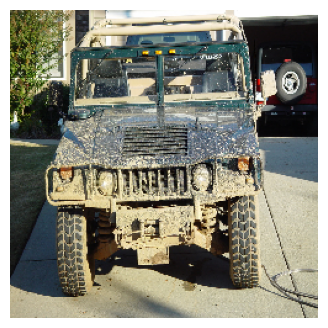

device: cuda


In [3]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed = 42
seed_everything(seed)
torch.backends.cudnn.benchmark = True

num_classes = 20
resize_size = 512
image_size = 448
batch_size = 8
accumulation_steps = 4
stage_1_epochs = 20
stage_2_epochs = 40
early_stop_patience = 8
num_workers = 2
use_tta = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights = VGG16_Weights.IMAGENET1K_V1
mean = weights.transforms().mean
std = weights.transforms().std

x_train = x_train.astype(np.uint8)
x_test = x_test.astype(np.uint8)
y_train = y_train.astype(np.int64).reshape(-1) - 1
y_test = y_test.astype(np.int64).reshape(-1) - 1

plt.figure(figsize=(4, 4))
plt.imshow(x_train[0])
plt.axis("off")
plt.show()

print("device:", device)


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((resize_size, resize_size)),
    transforms.RandomCrop(image_size),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=12, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

eval_transform = transforms.Compose([
    transforms.Resize((resize_size, resize_size)),
    transforms.CenterCrop(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

class CarsDataset(Dataset):
    def __init__(self, images, labels, transform):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = Image.fromarray(self.images[index])
        image = self.transform(image)
        label = torch.tensor(int(self.labels[index]), dtype=torch.long)
        return image, label

def make_pair_generator(loader, device):
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        yield [images, images], labels

train_dataset = CarsDataset(x_train, y_train, train_transform)
test_dataset = CarsDataset(x_test, y_test, eval_transform)

loader_kwargs = {
    "batch_size": batch_size,
    "num_workers": num_workers,
    "pin_memory": torch.cuda.is_available(),
    "persistent_workers": num_workers > 0,
}

train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

sample_inputs, sample_labels = next(make_pair_generator(train_loader, device))
print(sample_inputs[0].shape, sample_inputs[1].shape, sample_labels.shape)

torch.Size([8, 3, 448, 448]) torch.Size([8, 3, 448, 448]) torch.Size([8])


## 1. Model Architecture

The model uses two image inputs and one shared VGG16 feature extractor. Each input passes through the same convolutional stack, and the two feature maps are combined with bilinear pooling.

In [ ]:
def bilinear_pooling(left, right):
    batch_size, channels, height, width = left.shape
    left = left.view(batch_size, channels, height * width)
    right = right.view(batch_size, channels, height * width)
    
    #torch.bb instead of performing an einsum, equivalent.
    #batch_size x channels x (height*width)  @ batch_size x (height*width) x channels -> batch_size x channels x channels
    bilinear = torch.bmm(left, right.transpose(1, 2)) / float(height * width)

    #flatten the bilinear features to (batch_size, channels*channels)
    bilinear = bilinear.view(batch_size, channels * channels)
    
    #signed square root and l2 normalization.
    bilinear = torch.sign(bilinear) * torch.sqrt(torch.abs(bilinear) + 1e-6)
    bilinear = F.normalize(bilinear, p=2, dim=1)
    
    return bilinear

class BilinearVGG16(nn.Module):
    def __init__(self, num_classes=20):
        super().__init__()
        base_model = vgg16(weights=weights)
        self.backbone = base_model.features[:30]
        self.classifier = nn.Linear(512 * 512, num_classes)

    def forward(self, left, right):
        left_features = self.backbone(left)
        right_features = self.backbone(right)
        bilinear_features = bilinear_pooling(left_features, right_features)
        logits = self.classifier(bilinear_features)
        return logits

model = BilinearVGG16(num_classes=num_classes).to(device)
with torch.no_grad():
    dummy = torch.randn(2, 3, image_size, image_size, device=device)
    conv = model.backbone(dummy)
    bilinear = bilinear_pooling(conv, conv)
print("conv output:", tuple(conv.shape))
print("bilinear output:", tuple(bilinear.shape))
print(model)


conv output: (2, 512, 28, 28)
bilinear output: (2, 262144)
BilinearVGG16(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=Tru

## Training - Stage 1

Stage 1 freezes all VGG16 convolution weights and trains only the classifier. The training loop uses mixed precision, gradient accumulation, validation checkpointing, and patience-based early stopping.

In [6]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
scaler = torch.amp.GradScaler("cuda", enabled=torch.cuda.is_available())

def clone_state_dict(model):
    return {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

def evaluate(model, loader, criterion, use_tta=False):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for inputs, targets in make_pair_generator(loader, device):
            images = inputs[0]
            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=torch.cuda.is_available()):
                logits = model(images, images)
                if use_tta:
                    flipped_images = torch.flip(images, dims=[3])
                    flipped_logits = model(flipped_images, flipped_images)
                    logits = (logits + flipped_logits) / 2.0
                loss = criterion(logits, targets)
            running_loss += loss.item() * targets.size(0)
            running_correct += (logits.argmax(dim=1) == targets).sum().item()
            total += targets.size(0)

    return running_loss / total, running_correct / total

def run_epoch(model, loader, criterion, optimizer, accumulation_steps):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0
    optimizer.zero_grad(set_to_none=True)

    for step, (inputs, targets) in enumerate(make_pair_generator(loader, device), start=1):
        with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=torch.cuda.is_available()):
            logits = model(inputs[0], inputs[1])
            loss = criterion(logits, targets) / accumulation_steps
        scaler.scale(loss).backward()

        if step % accumulation_steps == 0 or step == len(loader):
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        running_loss += loss.item() * accumulation_steps * targets.size(0)
        running_correct += (logits.argmax(dim=1) == targets).sum().item()
        total += targets.size(0)

    return running_loss / total, running_correct / total

def fit_stage(model, train_loader, valid_loader, optimizer, scheduler, criterion, epochs, accumulation_steps, stage_name, best_accuracy=0.0, best_state=None):
    history = {"train_loss": [], "train_accuracy": [], "valid_loss": [], "valid_accuracy": []}
    epochs_without_improvement = 0

    for epoch in range(epochs):
        train_loss, train_accuracy = run_epoch(model, train_loader, criterion, optimizer, accumulation_steps)
        valid_loss, valid_accuracy = evaluate(model, valid_loader, criterion, use_tta=False)
        scheduler.step(valid_accuracy)

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["valid_loss"].append(valid_loss)
        history["valid_accuracy"].append(valid_accuracy)

        lr_info = ", ".join(
            f"group{i + 1}_lr={group['lr']:.2e}" for i, group in enumerate(optimizer.param_groups)
        )

        print(
            f"{stage_name} | epoch {epoch + 1:02d}/{epochs:02d} | "
            f"train_loss={train_loss:.4f} train_acc={train_accuracy:.4f} | "
            f"valid_loss={valid_loss:.4f} valid_acc={valid_accuracy:.4f} | "
            f"{lr_info}"
        )

        if valid_accuracy > best_accuracy:
            best_accuracy = valid_accuracy
            best_state = clone_state_dict(model)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= early_stop_patience:
            print(f"Early stopping in {stage_name} after {epoch + 1} epochs.")
            break

    return history, best_accuracy, best_state

for parameter in model.backbone.parameters():
    parameter.requires_grad = False

optimizer_stage_1 = torch.optim.AdamW(
    (parameter for parameter in model.parameters() if parameter.requires_grad),
    lr=3e-3,
    weight_decay=1e-4,
)
scheduler_stage_1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage_1,
    mode="max",
    factor=0.5,
    patience=2,
    min_lr=1e-5,
)

history_stage_1, best_accuracy, best_state = fit_stage(
    model=model,
    train_loader=train_loader,
    valid_loader=test_loader,
    optimizer=optimizer_stage_1,
    scheduler=scheduler_stage_1,
    criterion=criterion,
    epochs=stage_1_epochs,
    accumulation_steps=accumulation_steps,
    stage_name="Stage 1",
)


Stage 1 | epoch 01/20 | train_loss=2.8526 train_acc=0.1492 | valid_loss=2.5884 valid_acc=0.2691 | group1_lr=3.00e-03
Stage 1 | epoch 02/20 | train_loss=2.2381 train_acc=0.4437 | valid_loss=2.2365 valid_acc=0.3929 | group1_lr=3.00e-03
Stage 1 | epoch 03/20 | train_loss=1.8996 train_acc=0.5512 | valid_loss=2.0569 valid_acc=0.4388 | group1_lr=3.00e-03
Stage 1 | epoch 04/20 | train_loss=1.6372 train_acc=0.6536 | valid_loss=1.8662 valid_acc=0.5038 | group1_lr=3.00e-03
Stage 1 | epoch 05/20 | train_loss=1.4642 train_acc=0.7105 | valid_loss=1.8175 valid_acc=0.4745 | group1_lr=3.00e-03
Stage 1 | epoch 06/20 | train_loss=1.3207 train_acc=0.7674 | valid_loss=1.6762 valid_acc=0.5702 | group1_lr=3.00e-03
Stage 1 | epoch 07/20 | train_loss=1.1771 train_acc=0.8394 | valid_loss=1.6660 valid_acc=0.5536 | group1_lr=3.00e-03
Stage 1 | epoch 08/20 | train_loss=1.1081 train_acc=0.8319 | valid_loss=1.5529 valid_acc=0.6161 | group1_lr=3.00e-03
Stage 1 | epoch 09/20 | train_loss=1.0267 train_acc=0.8748 | val

## Training - Stage 2

Stage 2 restores the best stage-1 weights, unfreezes the full VGG16 backbone, and fine-tunes with discriminative learning rates so the classifier can adapt faster than the backbone.

In [7]:
model.load_state_dict(best_state)

for parameter in model.backbone.parameters():
    parameter.requires_grad = True

backbone_params = [parameter for parameter in model.backbone.parameters() if parameter.requires_grad]
classifier_params = [parameter for parameter in model.classifier.parameters() if parameter.requires_grad]

optimizer_stage_2 = torch.optim.AdamW(
    [
        {"params": backbone_params, "lr": 1e-5},
        {"params": classifier_params, "lr": 5e-5},
    ],
    weight_decay=1e-5,
)
scheduler_stage_2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_stage_2,
    mode="max",
    factor=0.5,
    patience=3,
    min_lr=[1e-6, 5e-6],
)

history_stage_2, best_accuracy, best_state = fit_stage(
    model=model,
    train_loader=train_loader,
    valid_loader=test_loader,
    optimizer=optimizer_stage_2,
    scheduler=scheduler_stage_2,
    criterion=criterion,
    epochs=stage_2_epochs,
    accumulation_steps=accumulation_steps,
    stage_name="Stage 2",
    best_accuracy=best_accuracy,
    best_state=best_state,
)


Stage 2 | epoch 01/40 | train_loss=0.5703 train_acc=0.9836 | valid_loss=1.1957 valid_acc=0.7194 | group1_lr=1.00e-05, group2_lr=5.00e-05
Stage 2 | epoch 02/40 | train_loss=0.5108 train_acc=0.9874 | valid_loss=1.1665 valid_acc=0.7258 | group1_lr=1.00e-05, group2_lr=5.00e-05
Stage 2 | epoch 03/40 | train_loss=0.4770 train_acc=0.9962 | valid_loss=1.1356 valid_acc=0.7538 | group1_lr=1.00e-05, group2_lr=5.00e-05
Stage 2 | epoch 04/40 | train_loss=0.4683 train_acc=0.9924 | valid_loss=1.1152 valid_acc=0.7385 | group1_lr=1.00e-05, group2_lr=5.00e-05
Stage 2 | epoch 05/40 | train_loss=0.4561 train_acc=0.9937 | valid_loss=1.1154 valid_acc=0.7500 | group1_lr=1.00e-05, group2_lr=5.00e-05
Stage 2 | epoch 06/40 | train_loss=0.4546 train_acc=0.9924 | valid_loss=1.1123 valid_acc=0.7474 | group1_lr=1.00e-05, group2_lr=5.00e-05
Stage 2 | epoch 07/40 | train_loss=0.4459 train_acc=0.9899 | valid_loss=1.1020 valid_acc=0.7538 | group1_lr=5.00e-06, group2_lr=2.50e-05
Stage 2 | epoch 08/40 | train_loss=0.4333

## Evaluation

The final evaluation restores the best checkpoint found across both stages and applies optional horizontal-flip test-time augmentation.

In [10]:
model.load_state_dict(best_state)

test_loss, test_accuracy = evaluate(model, test_loader, criterion, use_tta=use_tta)
print(f"Final test loss: {test_loss:.4f}")
print(f"Final test accuracy: {test_accuracy:.4f}")


Final test loss: 1.0665
Final test accuracy: 0.7717


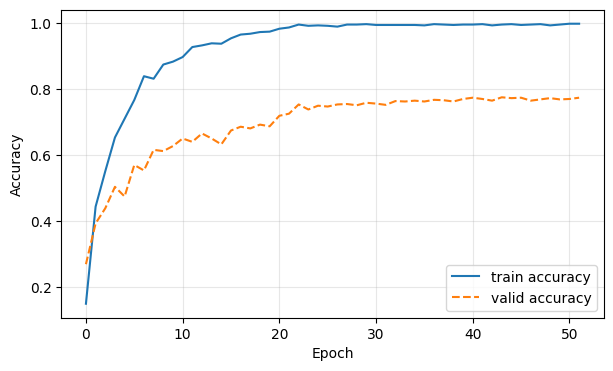

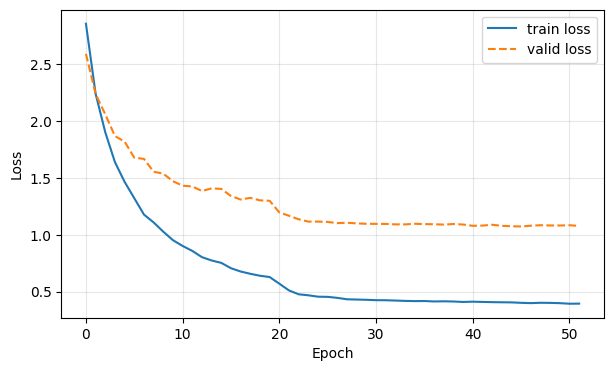

In [11]:
def merge_histories(*histories):
    merged = {"train_loss": [], "train_accuracy": [], "valid_loss": [], "valid_accuracy": []}
    for history in histories:
        for key in merged:
            merged[key].extend(history[key])
    return merged

full_history = merge_histories(history_stage_1, history_stage_2)

def plot_history(history, metric):
    plt.figure(figsize=(7, 4))
    plt.plot(history[f"train_{metric}"], label=f"train {metric}")
    plt.plot(history[f"valid_{metric}"], linestyle="--", label=f"valid {metric}")
    plt.xlabel("Epoch")
    plt.ylabel(metric.title())
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_history(full_history, "accuracy")
plot_history(full_history, "loss")
